renda_total: 0 nulos de 307511 (0.00%)
idade: 0 nulos de 307511 (0.00%)
anos_empregado: 55374 nulos de 307511 (18.01%)
tipo_contrato: 0 nulos de 307511 (0.00%)
escolaridade: 0 nulos de 307511 (0.00%)
ocupacao: 96391 nulos de 307511 (31.35%)
score_externo_1: 173378 nulos de 307511 (56.38%)
score_externo_2: 660 nulos de 307511 (0.21%)
score_externo_3: 60965 nulos de 307511 (19.83%)
Clientes sem vínculo empregatício (anomalia DAYS_EMPLOYED=365243 tratada): 55374 (18.01%)
Clientes duplicados por sk_id_curr: 0
Registros de bureau duplicados por sk_id_bureau: 0


summary,renda_total
min,25650.0
25%,112500.0
50%,146700.0
75%,202500.0
max,1.17E8


summary,idade
min,20
25%,33
50%,43
75%,53
max,69


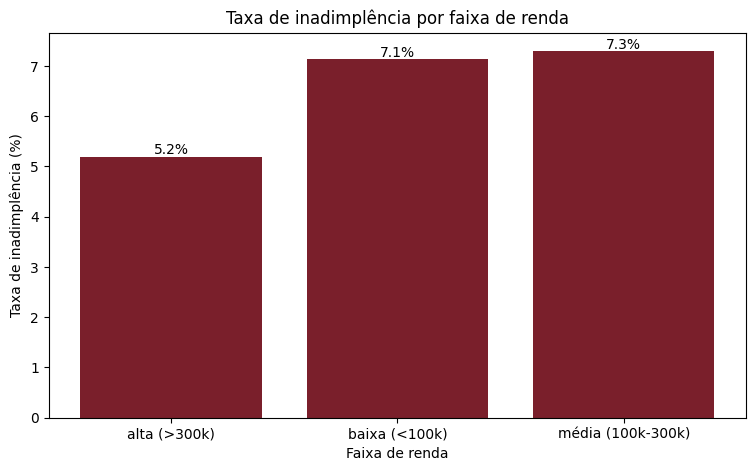

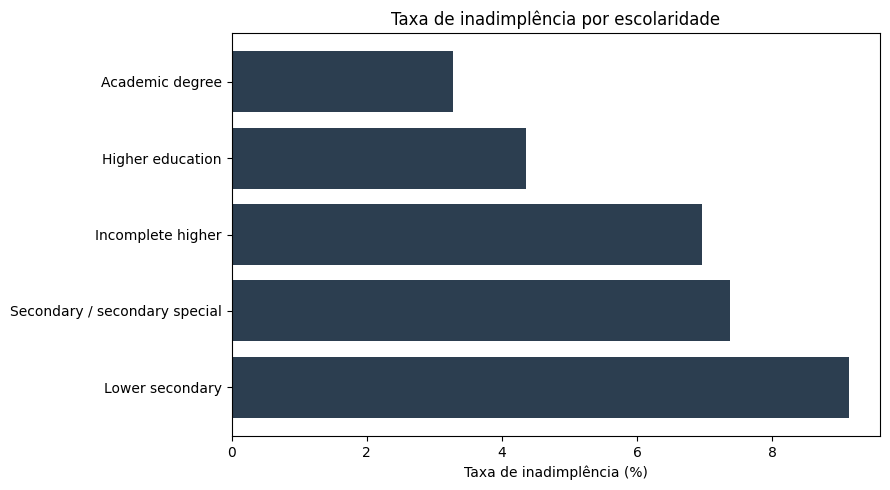

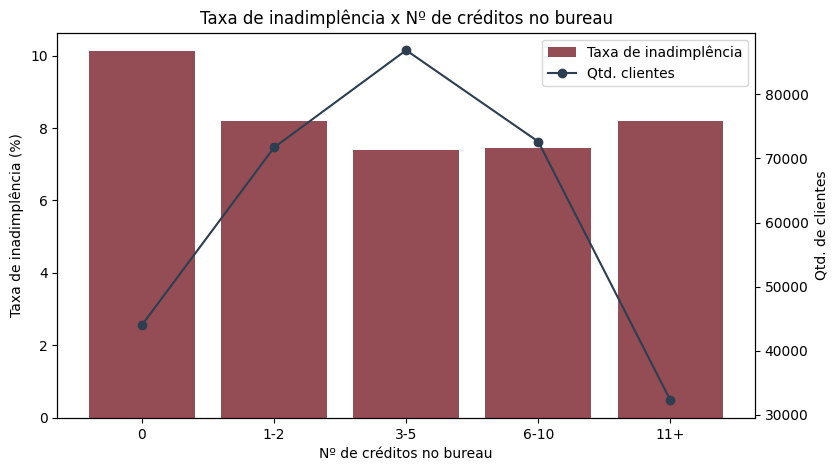

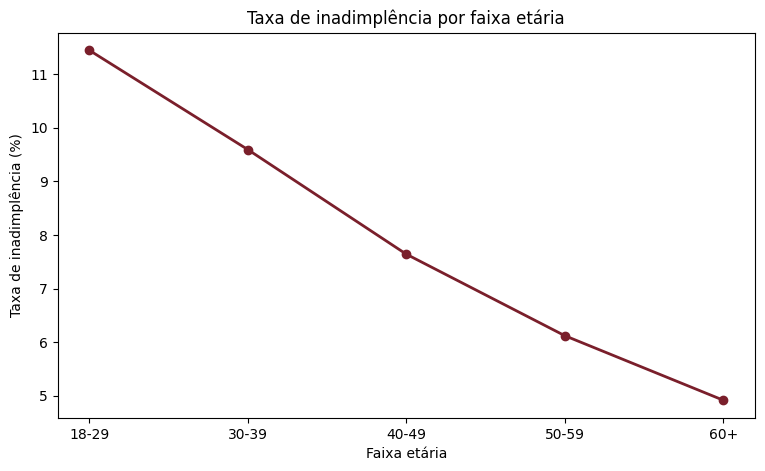

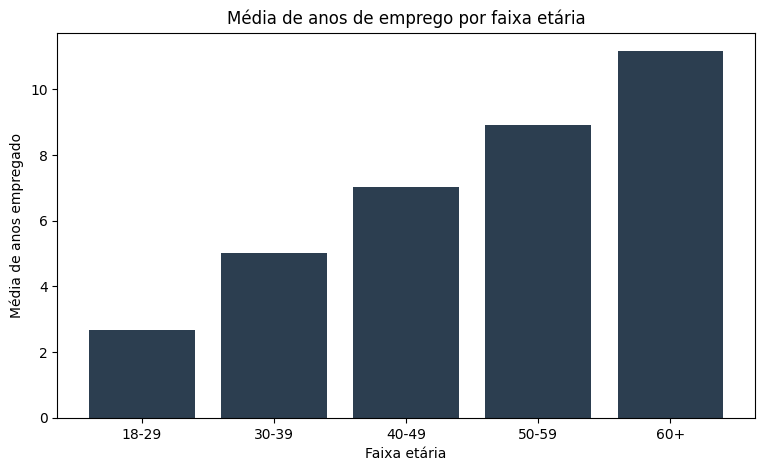

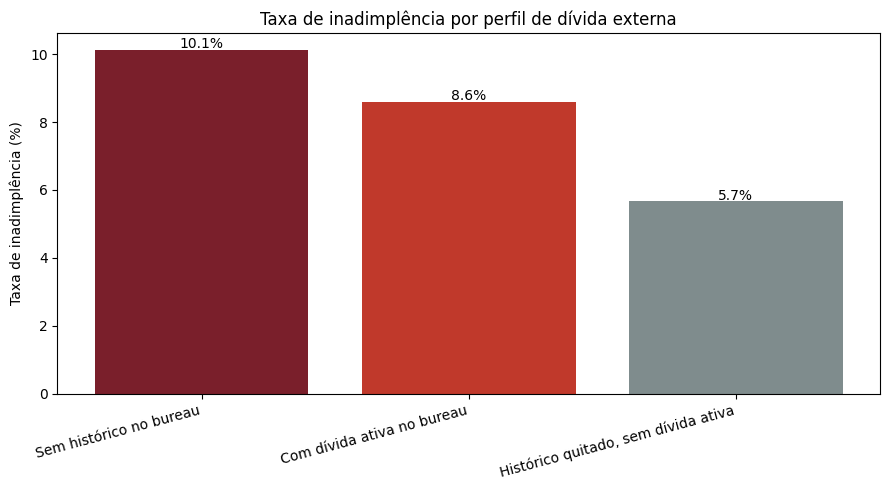

perfil_divida_externa,qtd_clientes,taxa_inadimplencia,media_divida_bureau
Sem histórico no bureau,44020,0.10124943207632894,0.0
Com dívida ativa no bureau,185146,0.08602400267896687,911939.260667657
"Histórico quitado, sem dívida ativa",78345,0.0566851745484715,-463.71286961516375


In [0]:
# Databricks notebook source
# MAGIC %md
# MAGIC # 04 — Qualidade de Dados e Análise Final
# MAGIC
# MAGIC Duas partes: (1) verificação de qualidade dos atributos-chave, (2) análise gráfica
# MAGIC respondendo cada pergunta do objetivo.

# COMMAND ----------

CATALOG = "mvp_credito"

from pyspark.sql import functions as F
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 5)

# COMMAND ----------

# MAGIC %md
# MAGIC ## Parte 1 — Qualidade de Dados

# COMMAND ----------

# MAGIC %md
# MAGIC ### Completude — % de nulos em atributos-chave

# COMMAND ----------

df = spark.table(f"{CATALOG}.silver.clientes")
total = df.count()

colunas_relevantes = [
    "renda_total", "idade", "anos_empregado", "tipo_contrato", "escolaridade",
    "ocupacao", "score_externo_1", "score_externo_2", "score_externo_3",
]
for c in colunas_relevantes:
    nulos = df.filter(F.col(c).isNull()).count()
    print(f"{c}: {nulos} nulos de {total} ({nulos/total:.2%})")

# MAGIC %md
# MAGIC **Observação:** `score_externo_1` tende a ter proporção alta de nulos — é esperado, pois
# MAGIC nem toda fonte externa tem cobertura de todos os clientes. `anos_empregado` é nulo por
# MAGIC construção para clientes sem vínculo empregatício (`sem_vinculo_empregaticio = true`),
# MAGIC tratamento já aplicado na Silver.

# COMMAND ----------

# MAGIC %md
# MAGIC ### Consistência — anomalia DAYS_EMPLOYED tratada

# COMMAND ----------

qtd_sem_vinculo = df.filter(F.col("sem_vinculo_empregaticio")).count()
print(f"Clientes sem vínculo empregatício (anomalia DAYS_EMPLOYED=365243 tratada): {qtd_sem_vinculo} ({qtd_sem_vinculo/total:.2%})")

# COMMAND ----------

# MAGIC %md
# MAGIC ### Unicidade — duplicatas de chave primária

# COMMAND ----------

duplicatas_clientes = total - df.select("sk_id_curr").distinct().count()
print("Clientes duplicados por sk_id_curr:", duplicatas_clientes)

df_bureau = spark.table(f"{CATALOG}.silver.historico_credito")
duplicatas_bureau = df_bureau.count() - df_bureau.select("sk_id_bureau").distinct().count()
print("Registros de bureau duplicados por sk_id_bureau:", duplicatas_bureau)

# COMMAND ----------

# MAGIC %md
# MAGIC ### Acurácia / outliers — renda e idade

# COMMAND ----------

display(df.select("renda_total").summary("min", "25%", "50%", "75%", "max"))

# MAGIC %md
# MAGIC **Observação:** é conhecido nesse dataset que `AMT_INCOME_TOTAL` (renda_total) tem um
# MAGIC outlier extremo (valor na casa de dezenas de milhões), muito acima do percentil 99. Para
# MAGIC não distorcer as análises de faixa de renda (Pergunta 1), aplicamos um corte no percentil
# MAGIC 99 apenas nas visualizações abaixo — as tabelas Gold mantêm o dado original, já que a
# MAGIC exclusão de linhas não é necessária para as agregações por faixa.

# COMMAND ----------

display(df.select("idade").summary("min", "25%", "50%", "75%", "max"))

# COMMAND ----------

# MAGIC %md
# MAGIC ## Parte 2 — Análise Final: respondendo as perguntas de negócio

# COMMAND ----------

# MAGIC %md
# MAGIC ### Pergunta 1: Taxa de inadimplência por faixa de renda, tipo de contrato e escolaridade

# COMMAND ----------

pdf_segmento = (
    spark.table(f"{CATALOG}.gold.agg_risco_por_segmento")
    .groupBy("faixa_renda")
    .agg(F.avg("taxa_inadimplencia").alias("taxa_inadimplencia"), F.sum("qtd_clientes").alias("qtd_clientes"))
    .orderBy("faixa_renda")
    .toPandas()
)

fig, ax = plt.subplots()
ax.bar(pdf_segmento["faixa_renda"], pdf_segmento["taxa_inadimplencia"] * 100, color="#7A1F2B")
ax.set_title("Taxa de inadimplência por faixa de renda")
ax.set_ylabel("Taxa de inadimplência (%)")
ax.set_xlabel("Faixa de renda")
for i, v in enumerate(pdf_segmento["taxa_inadimplencia"] * 100):
    ax.text(i, v + 0.05, f"{v:.1f}%", ha="center")
plt.show()

# COMMAND ----------

pdf_escolaridade = (
    spark.table(f"{CATALOG}.gold.agg_risco_por_segmento")
    .groupBy("escolaridade")
    .agg(F.avg("taxa_inadimplencia").alias("taxa_inadimplencia"))
    .orderBy(F.desc("taxa_inadimplencia"))
    .toPandas()
)

fig, ax = plt.subplots()
ax.barh(pdf_escolaridade["escolaridade"], pdf_escolaridade["taxa_inadimplencia"] * 100, color="#2C3E50")
ax.set_title("Taxa de inadimplência por escolaridade")
ax.set_xlabel("Taxa de inadimplência (%)")
plt.tight_layout()
plt.show()

# MAGIC %md
# MAGIC **Discussão:** *(preencher após rodar: qual faixa de renda concentra maior risco? a
# MAGIC escolaridade mostra um gradiente claro? isso é coerente com o que você observa na sua
# MAGIC experiência profissional em risco de crédito?)*

# COMMAND ----------

# MAGIC %md
# MAGIC ### Pergunta 2: Clientes com mais créditos no bureau têm maior taxa de default?

# COMMAND ----------

pdf_bureau = (
    spark.table(f"{CATALOG}.gold.agg_risco_por_bureau")
    .toPandas()
)
ordem = ["0", "1-2", "3-5", "6-10", "11+"]
pdf_bureau["faixa_qtd_creditos"] = pdf_bureau["faixa_qtd_creditos"].astype("category")
pdf_bureau["faixa_qtd_creditos"] = pdf_bureau["faixa_qtd_creditos"].cat.set_categories(ordem)
pdf_bureau = pdf_bureau.sort_values("faixa_qtd_creditos")

fig, ax1 = plt.subplots()
ax1.bar(pdf_bureau["faixa_qtd_creditos"], pdf_bureau["taxa_inadimplencia"] * 100, color="#7A1F2B", alpha=0.8, label="Taxa de inadimplência")
ax1.set_ylabel("Taxa de inadimplência (%)")
ax1.set_xlabel("Nº de créditos no bureau")
ax2 = ax1.twinx()
ax2.plot(pdf_bureau["faixa_qtd_creditos"], pdf_bureau["qtd_clientes"], color="#2C3E50", marker="o", label="Qtd. clientes")
ax2.set_ylabel("Qtd. de clientes")
ax1.set_title("Taxa de inadimplência x Nº de créditos no bureau")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
plt.show()

# MAGIC %md
# MAGIC **Discussão:** *(preencher: a relação é crescente, decrescente ou em U? clientes sem
# MAGIC nenhum crédito no bureau têm risco diferente dos demais?)*

# COMMAND ----------

# MAGIC %md
# MAGIC ### Pergunta 3: A idade e o tempo de emprego influenciam o risco de inadimplência?

# COMMAND ----------

pdf_idade = spark.table(f"{CATALOG}.gold.agg_risco_por_idade").toPandas()

fig, ax = plt.subplots()
ax.plot(pdf_idade["faixa_etaria"], pdf_idade["taxa_inadimplencia"] * 100, marker="o", color="#7A1F2B", linewidth=2)
ax.set_title("Taxa de inadimplência por faixa etária")
ax.set_ylabel("Taxa de inadimplência (%)")
ax.set_xlabel("Faixa etária")
plt.show()

# COMMAND ----------

fig, ax = plt.subplots()
ax.bar(pdf_idade["faixa_etaria"], pdf_idade["media_anos_empregado"], color="#2C3E50")
ax.set_title("Média de anos de emprego por faixa etária")
ax.set_ylabel("Média de anos empregado")
ax.set_xlabel("Faixa etária")
plt.show()

# MAGIC %md
# MAGIC **Discussão:** *(preencher: clientes mais jovens têm mais risco? isso se relaciona com
# MAGIC menor tempo de emprego?)*

# COMMAND ----------

# MAGIC %md
# MAGIC ### Pergunta 4: Clientes com dívida ativa externa têm perfil de risco diferente?

# COMMAND ----------

pdf_divida = spark.table(f"{CATALOG}.gold.agg_risco_por_divida_externa").toPandas()

fig, ax = plt.subplots()
cores = ["#7A1F2B", "#C0392B", "#7F8C8D"]
ax.bar(pdf_divida["perfil_divida_externa"], pdf_divida["taxa_inadimplencia"] * 100, color=cores[: len(pdf_divida)])
ax.set_title("Taxa de inadimplência por perfil de dívida externa")
ax.set_ylabel("Taxa de inadimplência (%)")
plt.xticks(rotation=15, ha="right")
for i, v in enumerate(pdf_divida["taxa_inadimplencia"] * 100):
    ax.text(i, v + 0.05, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()

display(pdf_divida)

# MAGIC %md
# MAGIC **Discussão:** *(preencher: clientes sem histórico externo são mais ou menos arriscados
# MAGIC do que os com dívida ativa? o que isso sugere sobre usar dados de bureau como variável de
# MAGIC política de crédito?)*

# COMMAND ----------

# MAGIC %md
# MAGIC ## Discussão geral
# MAGIC *(Conectar as quatro respostas ao problema original definido no README: quais fatores mais
# MAGIC se destacaram, quais tiveram resultado surpreendente, e como isso poderia orientar uma
# MAGIC política de crédito real.)*
